In [52]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

from MixedEffectsModeling.validation import lobo_mmd

LOBO = Path('./LOBO_Results_mixed')
FIG = LOBO / 'Figures'
FIG.mkdir(parents=True, exist_ok=True)

In [53]:
def _p_to_asterisk(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''


def _short_batch_label(batch):
    name, _, num = batch.replace(' et al.', '').partition('_Batch_')
    return f'{name}_{num}' if num else name


def plot_mmd_bar(df, out_path):
    d = df.sort_values('mmd2', ascending=False).reset_index(drop=True)
    labels = [_short_batch_label(b) for b in d['batch']]
    fig, ax = plt.subplots(figsize=(4, 6))
    bars = ax.bar(range(len(d)), d['mmd2'], color='#00C78B')
    y_span = d['mmd2'].max() - d['mmd2'].min()
    for bar, p in zip(bars, d['perm_p']):
        label = _p_to_asterisk(p)
        if not label:
            continue
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01 * y_span, label, ha='center', va='bottom', fontsize=10)
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('MMD$^2$ (held-out HC vs disease)')
    ax.set_xlabel('LOBO batch')
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches='tight')
    return fig


def plot_mmd_direction(df, out_path):
    # p_direction: Mann-Whitney U, D_D (disease-to-HC-mean embedding) > D_H (HC-to-leave-one-out-HC-mean
    # embedding), both computed in the SAME RKHS (same RBF kernel/gamma) as the MMD test above, from
    # this batch's own LOBO-scored held-out samples only (lobo_mmd._ref_centroid_direction) -- shown
    # as an asterisk at the midpoint of each row's segment.
    d = df.sort_values('mmd2', ascending=False).reset_index(drop=True)
    labels = [_short_batch_label(b) for b in d['batch']]
    y = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hlines(y, d['hc_ref_dist'], d['dis_ref_dist'],
             color=np.where(d['disease_farther'], '#00C78B', '#999999'), linewidth=3)
    ax.scatter(d['hc_ref_dist'], y, color='#A4AFB8', label='held-out HC', zorder=3, s=90, edgecolors='black', linewidth=0.5)
    ax.scatter(d['dis_ref_dist'], y, color='#00C78B', label='disease', zorder=3, s=90, edgecolors='black', linewidth=0.5)
    if 'p_direction' in d.columns:
        xmid = (d['hc_ref_dist'] + d['dis_ref_dist']) / 2
        for yi, xi, p in zip(y, xmid, d['p_direction']):
            label = _p_to_asterisk(p)
            if label:
                ax.text(xi, yi - 0.08, label, ha='center', va='bottom', fontsize=10)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Kernel embedding distance from HC reference')
    ax.set_ylabel('LOBO batch')
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1.0))
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches='tight')
    return fig

In [54]:
# 0. Raw MMD summary (held-out HC vs held-out disease, per Tier-A batch with n_hc >= lobo_mmd.MIN_N_HC)
# no SHASH correction -- Z_test.npy / cv_zscores.pkl are used exactly as scored
df_raw = lobo_mmd.mmd_summary_cached(force=False, shash=False)
print(df_raw.to_string(index=False))

n_sig_raw = int(((df_raw['perm_p'] < 0.05) & df_raw['disease_farther']).sum())
print(f"\n{n_sig_raw}/{len(df_raw)} batches: MMD significant (p<0.05) AND disease farther "
     f"from the in-fold HC reference than the held-out-HC noise floor. (raw, no SHASH)")

                          batch  n_hc  n_dis     mmd2   perm_p  hc_ref_dist  dis_ref_dist  disease_farther  p_direction
          Ward Z et al._Batch_1   116    224 0.057589 0.000999     0.743065      0.831780             True 6.384674e-15
           Moore et al._Batch_1    71    173 0.000736 0.224775     0.769388      0.796322             True 9.999055e-03
Roskams-Hieter B et al._Batch_2    27     58 0.009790 0.036963     0.751264      0.798519             True 7.734418e-03
       Moufarrej et al._Batch_4    47     39 0.009684 0.058941     0.757603      0.818075             True 2.540148e-03
            Chen et al._Batch_2    31     32 0.024635 0.011988     0.753432      0.806670             True 3.221963e-02
       Moufarrej et al._Batch_1    54     23 0.034273 0.002997     0.782444      0.819002             True 2.111909e-02

4/6 batches: MMD significant (p<0.05) AND disease farther from the in-fold HC reference than the held-out-HC noise floor. (raw, no SHASH)


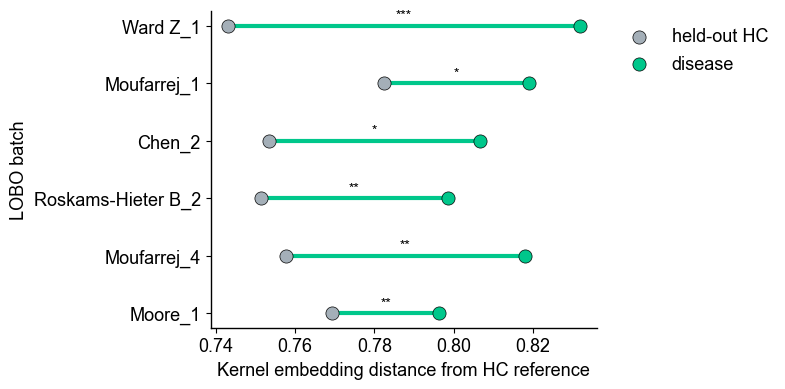

In [55]:
# 1. Raw MMD plots
plot_mmd_bar(df_raw, FIG / 'mmd_bar.png')
plot_mmd_direction(df_raw, FIG / 'mmd_direction.png')

In [56]:
# 2. SHASH-corrected MMD summary -- each gene's already-fit SHASH transform (cv_stats.csv)
# applied to both the LOBO Z and the CV-reference centroid before the comparison
df_shash = lobo_mmd.mmd_summary_cached(force=False, shash=True)
print(df_shash.to_string(index=False))

n_sig_shash = int(((df_shash['perm_p'] < 0.05) & df_shash['disease_farther']).sum())
print(f"\n{n_sig_shash}/{len(df_shash)} batches: MMD significant (p<0.05) AND disease farther "
     f"from the in-fold HC reference than the held-out-HC noise floor. (SHASH-corrected)")

                          batch  n_hc  n_dis     mmd2   perm_p  hc_ref_dist  dis_ref_dist  disease_farther  p_direction
          Ward Z et al._Batch_1   116    224 0.056042 0.000999   126.223709    147.801590             True 1.621063e-11
           Moore et al._Batch_1    71    173 0.000607 0.241758   130.790573    136.294479             True 2.600932e-02
Roskams-Hieter B et al._Batch_2    27     58 0.009380 0.049950   133.390350    146.355469             True 1.310842e-02
       Moufarrej et al._Batch_4    47     39 0.008214 0.086913   125.125175    138.711533             True 3.871173e-03
            Chen et al._Batch_2    31     32 0.023514 0.015984   131.648422    144.836655             True 2.586549e-02
       Moufarrej et al._Batch_1    54     23 0.033397 0.005994   123.172890    132.352631             True 5.764563e-02

4/6 batches: MMD significant (p<0.05) AND disease farther from the in-fold HC reference than the held-out-HC noise floor. (SHASH-corrected)


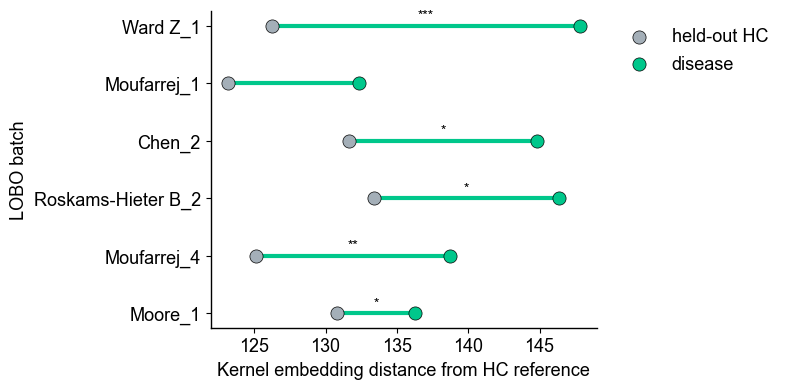

In [57]:
# 3. SHASH-corrected MMD plots
plot_mmd_bar(df_shash, FIG / 'mmd_bar_shash.png')
plot_mmd_direction(df_shash, FIG / 'mmd_direction_shash.png')

In [58]:
# 4. Raw vs SHASH-corrected, side by side -- does the raw-scale call survive de-skewing?
cmp = df_raw.merge(df_shash, on='batch', suffixes=('_raw', '_shash'))
cmp['sig_raw'] = (cmp['perm_p_raw'] < 0.05) & cmp['disease_farther_raw']
cmp['sig_shash'] = (cmp['perm_p_shash'] < 0.05) & cmp['disease_farther_shash']
print(cmp[['batch', 'mmd2_raw', 'perm_p_raw', 'sig_raw', 'mmd2_shash', 'perm_p_shash', 'sig_shash']].to_string(index=False))
print(f"\nagree (both sig or both not): {(cmp['sig_raw'] == cmp['sig_shash']).sum()}/{len(cmp)}")

                          batch  mmd2_raw  perm_p_raw  sig_raw  mmd2_shash  perm_p_shash  sig_shash
          Ward Z et al._Batch_1  0.057589    0.000999     True    0.056042      0.000999       True
           Moore et al._Batch_1  0.000736    0.224775    False    0.000607      0.241758      False
Roskams-Hieter B et al._Batch_2  0.009790    0.036963     True    0.009380      0.049950       True
       Moufarrej et al._Batch_4  0.009684    0.058941    False    0.008214      0.086913      False
            Chen et al._Batch_2  0.024635    0.011988     True    0.023514      0.015984       True
       Moufarrej et al._Batch_1  0.034273    0.002997     True    0.033397      0.005994       True

agree (both sig or both not): 6/6


In [59]:
from MixedEffectsModeling.validation.lobo_engine import compute_ood

compute_ood()

Chang et al._Batch_1                     n_test=  30  removed_OOD=  9 (30.0%)
Chang et al._Batch_11                    n_test=  35  removed_OOD=  1 (2.9%)
Chang et al._Batch_2                     n_test=  37  removed_OOD=  0 (0.0%)
Chang et al._Batch_3                     n_test=  30  removed_OOD=  1 (3.3%)
Chang et al._Batch_4                     n_test=  33  removed_OOD=  0 (0.0%)
Chang et al._Batch_5                     n_test=  25  removed_OOD=  0 (0.0%)
Chen et al._Batch_2                      n_test=  63  removed_OOD=  8 (12.7%)
Gardella et al._Batch_1                  n_test=  30  removed_OOD=  0 (0.0%)
Gardella et al._Batch_3                  n_test=  14  removed_OOD=  1 (7.1%)
Gardella et al._Batch_4                  n_test=  46  removed_OOD=  1 (2.2%)
Gardella et al._Batch_5                  n_test=  32  removed_OOD=  0 (0.0%)
Gardella et al._Batch_7                  n_test=  17  removed_OOD=  0 (0.0%)
Moore et al._Batch_1                     n_test= 244  removed_OOD= 16 (6.6

In [60]:
# OOD-filtered MMD, raw and SHASH-corrected
df_ood = lobo_mmd.mmd_summary_cached(force=False, shash=False, ood_filter=True)
df_shash_ood = lobo_mmd.mmd_summary_cached(force=False, shash=True, ood_filter=True)

for label, d in [('ood', df_ood), ('shash+ood', df_shash_ood)]:
    n_sig = int(((d['perm_p'] < 0.05) & d['disease_farther']).sum())
    print(f"[{label}] {n_sig}/{len(d)} batches significant (p<0.05) AND disease farther")
print()
print(df_shash_ood.to_string(index=False))

[ood] 4/6 batches significant (p<0.05) AND disease farther
[shash+ood] 4/6 batches significant (p<0.05) AND disease farther

                          batch  n_hc  n_dis      mmd2   perm_p  hc_ref_dist  dis_ref_dist  disease_farther  p_direction
          Ward Z et al._Batch_1   105    190  0.054047 0.000999   127.642662    146.287338             True 1.143542e-08
           Moore et al._Batch_1    67    161 -0.000169 0.371628   129.941757    135.072250             True 3.237367e-02
Roskams-Hieter B et al._Batch_2    26     57  0.010321 0.043956   133.070053    145.662140             True 1.375653e-02
       Moufarrej et al._Batch_4    42     30  0.006050 0.152847   124.365463    135.578934             True 1.394807e-02
            Chen et al._Batch_2    27     28  0.028462 0.007992   128.332031    143.143051             True 1.730456e-02
       Moufarrej et al._Batch_1    47     18  0.035698 0.010989   122.013985    135.405151             True 3.183470e-02


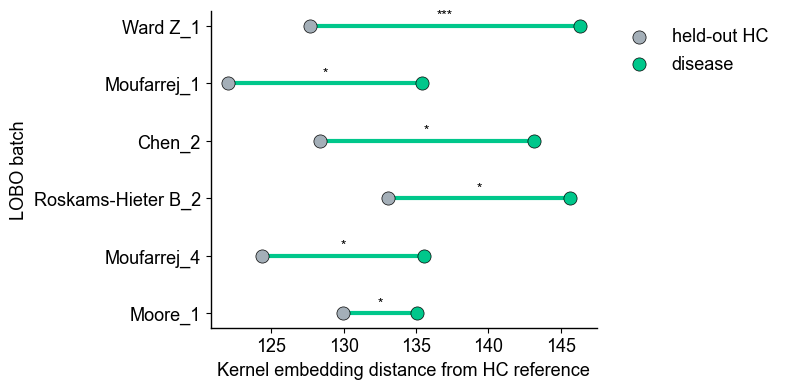

In [61]:
# shash+ood plots (the most rigorous variant: batch-refit + SHASH-decorrelated + extrapolation-flagged)
plot_mmd_bar(df_shash_ood, FIG / 'mmd_bar_shash_ood.png')
plot_mmd_direction(df_shash_ood, FIG / 'mmd_direction_shash_ood.png')

In [62]:
# All 4 variants side by side -- does the raw-scale call survive de-skewing AND extrapolation-flagging?
variants = {'raw': df_raw, 'shash': df_shash, 'ood': df_ood, 'shash_ood': df_shash_ood}
sig = pd.DataFrame({name: (d.set_index('batch')['perm_p'] < 0.05) & d.set_index('batch')['disease_farther']
                    for name, d in variants.items()})
mmd2 = pd.DataFrame({name: d.set_index('batch')['mmd2'] for name, d in variants.items()})

print('significant (p<0.05) AND disease farther, per variant:')
print(sig.to_string())
print(f"\nagree across all 4 variants: {(sig.nunique(axis=1) == 1).sum()}/{len(sig)} batches")
print('\nmmd2 by variant:')
print(mmd2.round(4).to_string())

significant (p<0.05) AND disease farther, per variant:
                                   raw  shash    ood  shash_ood
batch                                                          
Ward Z et al._Batch_1             True   True   True       True
Moore et al._Batch_1             False  False  False      False
Roskams-Hieter B et al._Batch_2   True   True   True       True
Moufarrej et al._Batch_4         False  False  False      False
Chen et al._Batch_2               True   True   True       True
Moufarrej et al._Batch_1          True   True   True       True

agree across all 4 variants: 6/6 batches

mmd2 by variant:
                                    raw   shash     ood  shash_ood
batch                                                             
Ward Z et al._Batch_1            0.0576  0.0560  0.0552     0.0540
Moore et al._Batch_1             0.0007  0.0006  0.0001    -0.0002
Roskams-Hieter B et al._Batch_2  0.0098  0.0094  0.0105     0.0103
Moufarrej et al._Batch_4         0.009

In [63]:
# 5. Batch-matched per-sample deviation (supporting). MMD above is a distribution-level distance;
# this asks the same question one sample at a time. Each batch's held-out HC and its disease samples
# are scored by the SAME LOBO engine (that batch withheld), so null and observation share batch and
# model. n_sig = BH-significant genes in a single sample; AUC = P(a disease sample deviates more
# than an HC sample from the same batch), 0.5 being no signal.
import json
import pickle

import seaborn as sns
from scipy.stats import mannwhitneyu, norm

from MixedEffectsModeling.core.calibration import bh_fdr_reject
from MixedEffectsModeling.core.shash import shash_correct_matrix

FDR_Q, Z_CAP = 0.05, 10.0
NSIG_PATH = LOBO / 'lobo_nsig.csv'
lobo_meta = sorted(LOBO.glob('*/meta.json'))

if NSIG_PATH.exists():
    nsig = pd.read_csv(NSIG_PATH)
else:
    # Per-batch leave-one-batch-out SHASH (lobo_mmd.loo_shash_params), fit on held-out HC from
    # every OTHER batch -- NOT the CV-pooled params, which leak this batch's own within-batch
    # CV folds into its own correction (CV splits within every batch, never excludes one).
    loaded = lobo_mmd._load_all_batches_hc()
    rows = []
    for p in lobo_meta:
        m = json.load(open(p))
        genes = pickle.load(open(p.parent / 'gene_names.pkl', 'rb'))
        batch = m['batch_id']
        params = lobo_mmd.loo_shash_params(batch, loaded, genes)
        Zb = np.nan_to_num(np.load(p.parent / 'Z_test.npy').astype(np.float32), nan=0.0)
        Zb = np.clip(shash_correct_matrix(Zb, genes, params), -Z_CAP, Z_CAP)
        ns = [int(bh_fdr_reject(r, q=FDR_Q).sum()) for r in 2 * norm.sf(np.abs(Zb))]
        rows += [(batch, nm, bool(hc), v)
                 for nm, hc, v in zip(m['test_names'], m['test_is_hc'], ns)]
    nsig = pd.DataFrame(rows, columns=['batch', 'sample', 'is_hc', 'n_sig'])
    nsig.to_csv(NSIG_PATH, index=False)

rows = []
for b, g in nsig.groupby('batch'):
    h = g.loc[g['is_hc'], 'n_sig'].values
    d = g.loc[~g['is_hc'], 'n_sig'].values
    if len(h) == 0 or len(d) == 0:
        continue
    u, pu = mannwhitneyu(d, h, alternative='greater')
    rows.append(dict(batch=b, n_hc=len(h), n_dis=len(d), hc_med=np.median(h), dis_med=np.median(d),
                     auc=u / (len(d) * len(h)), mw_p=pu))
nsig_stats = pd.DataFrame(rows).sort_values('auc', ascending=False)
nsig_stats.to_csv(LOBO / 'batch_matched_nsig_stats.csv', index=False)

# same test on true nulls: HC vs the rest of its own batch's HC, must stay at or under 0.05
fp = [((np.delete(h, i) >= h[i]).sum() + 1) / len(h)
      for _, g in nsig.groupby('batch')
      for h in [g.loc[g['is_hc'], 'n_sig'].values] if len(h) >= 19
      for i in range(len(h))]

print(f"batches with both HC and disease: {len(nsig_stats)}  "
      f"AUC>0.5: {(nsig_stats['auc'] > 0.5).sum()}  "
      f"Mann-Whitney p<0.05: {(nsig_stats['mw_p'] < 0.05).sum()}")
print(f"HC-vs-HC leave-one-out false-positive rate: {np.mean(np.array(fp) < 0.05):.4f} "
      f"(target 0.05, n={len(fp)})\n")
print(nsig_stats.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

AttributeError: module 'MixedEffectsModeling.validation.lobo_mmd' has no attribute '_load_all_batches_hc'

In [ ]:
# 6. Batch-matched null vs observation, and the within-batch effect size
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

order = nsig_stats.sort_values('auc')['batch'].tolist()
plot = nsig[nsig['batch'].isin(order)].copy()
plot['group'] = np.where(plot['is_hc'], 'HC (held-out)', 'Disease')
labels = [_short_batch_label(b) for b in order]

sns.stripplot(data=plot, y='batch', x='n_sig', hue='group', order=order,
              hue_order=['HC (held-out)', 'Disease'], palette=['#8c8c8c', '#2a6099'],
              dodge=True, orient='h', size=3, alpha=0.6, jitter=0.25, ax=axes[0])
axes[0].set_xscale('symlog')
axes[0].set_xlim(left=-0.1)
axes[0].set_yticklabels(labels)
axes[0].set_xlabel('BH-significant genes per sample (q=0.05)')
axes[0].set_ylabel('')
axes[0].set_title('Batch-matched null and observation\n(same batch, same LOBO engine)')
axes[0].legend(frameon=False, fontsize=8, loc='lower right')

d = nsig_stats.sort_values('auc')
axes[1].hlines(range(len(d)), 0.5, d['auc'], color='#cccccc', lw=1.2, zorder=1)
axes[1].scatter(d['auc'], range(len(d)), s=np.clip(d['n_dis'], 10, 120),
                color=np.where(d['mw_p'] < 0.05, '#2a6099', '#aec6e8'), zorder=3)
axes[1].axvline(0.5, color='#d64545', ls='--', lw=1.2)
axes[1].text(0.5, len(d) - 0.4, ' no signal', color='#d64545', fontsize=8, ha='left')
axes[1].set_yticks(range(len(d)))
axes[1].set_yticklabels([f"{_short_batch_label(b)} {_p_to_asterisk(p)}"
                         for b, p in zip(d['batch'], d['mw_p'])], fontsize=8)
axes[1].set_xlabel('AUC: P(disease deviates more than HC, same batch)')
axes[1].set_title('Within-batch effect size\n(point size = n disease; filled = p<0.05)')

plt.tight_layout()
fig.savefig(FIG / 'batch_matched_nsig.png', bbox_inches='tight')

/tmp/ipykernel_131852/837038420.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(labels)
